# Which signal parameters get eaten? (representational harm across all signals)

Feed every signal of one generator and rank the parameters by how badly the patch tokeniser eats them.
The harm is **representational**, not next-step MAE: at integer `cpp` consecutive patches become
identical, so `1 - redundancy` = the model's ability to tell the signal advanced by one patch -> ~0 on
the blind spots. (Forecast MAE is dropped here: a phase-locked tone is trivially periodic, so MAE is
*lower* at blind spots and only confounds the picture - see the layer-probing notebook for the proof
of irreversibility.)

## Setup

In [30]:
import torch, os, re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from chronos import BaseChronosPipeline
np.random.seed(42); torch.manual_seed(42)
OUT = Path("../outputs/"); OUT.mkdir(parents=True, exist_ok=True)
SIGNALS_DIR = "../data/synthetic/signals/"

pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-bolt-tiny", device_map="cpu")
model = pipeline.model; cfg = model.config.chronos_config
P, S_DEF, PRED_LEN = cfg["input_patch_size"], cfg["input_patch_stride"], cfg["prediction_length"]
print(f"P={P} S={S_DEF}  blind spots at cpp = {[m*P/S_DEF for m in range(1, S_DEF//2+1)]}")

P=16 S=16  blind spots at cpp = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]


In [31]:
def parse_name(f):
    grab = lambda p, c=float: (c(re.search(p, f).group(1)) if re.search(p, f) else None)
    return dict(generator="KernelSynth" if "kernelsynth" in f.lower() else "TSMixup",
                cpp=grab(r"_cpp([0-9.]+)"), hz=grab(r"_hz([0-9.]+)"),
                fs=grab(r"_fs([0-9]+)", int) or 256, phase=grab(r"_ph([0-9.]+)") or 0.0)
def cut_into_patches(x, P, S): return np.stack([x[i:i+P] for i in range(0, len(x)-P+1, S)])
def adjacent_cos(M):
    M = np.asarray(M, float)
    s = [np.dot(M[i], M[i+1])/(np.linalg.norm(M[i])*np.linalg.norm(M[i+1])+1e-12) for i in range(len(M)-1)]
    return float(np.mean(s)) if s else np.nan
def effective_rank(M):
    M = np.asarray(M, float); M = M - M.mean(0, keepdims=True)
    sv = np.linalg.svd(M, compute_uv=False); sv = sv[sv > 1e-12]
    if sv.size == 0: return 0.0
    p = sv/sv.sum(); return float(np.exp(-(p*np.log(p)).sum()))

def embed_tokens(sig, stride=S_DEF):
    """Patch-embedding token matrix (K x d_model) for a signal."""
    cap = {}; model.patch.patch_stride = stride
    h = model.input_patch_embedding.register_forward_hook(lambda m,i,o: cap.__setitem__("e", o.detach().cpu().numpy()[0]))
    ctx = sig[:len(sig)-PRED_LEN]
    with torch.no_grad():
        pipeline.predict(torch.tensor(np.asarray(ctx, np.float32)).unsqueeze(0), prediction_length=PRED_LEN)
    h.remove(); model.patch.patch_stride = S_DEF
    return cap["e"]

## The mechanism in one picture
Integer cpp -> whole cycles per patch -> identical patch rows. Off it -> rows differ.

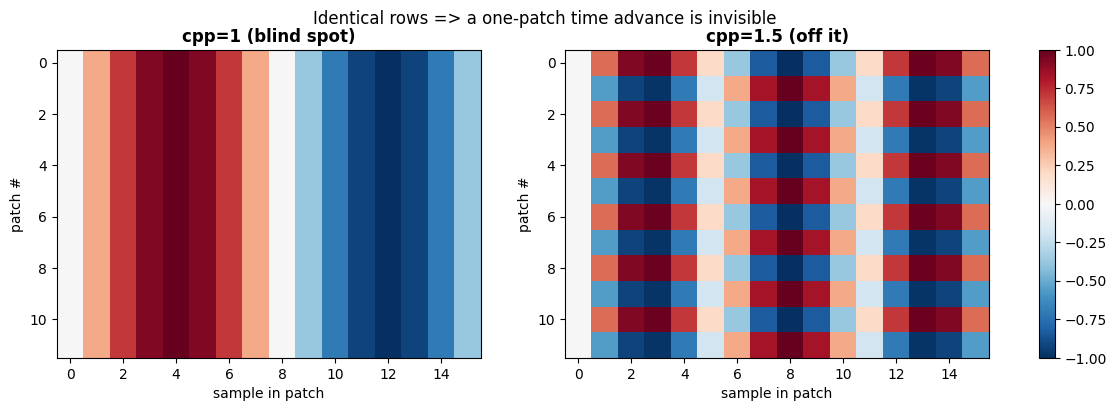

In [32]:
t = np.arange(512)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, c, lbl in [(axes[0], 1.0, "cpp=1 (blind spot)"), (axes[1], 1.5, "cpp=1.5 (off it)")]:
    pm = cut_into_patches(np.sin(2*np.pi*(c/P)*t), P, S_DEF)[:12]
    im = ax.imshow(pm, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_title(lbl, fontweight="bold"); ax.set_xlabel("sample in patch"); ax.set_ylabel("patch #")
fig.colorbar(im, ax=axes, fraction=0.025)
plt.suptitle("Identical rows => a one-patch time advance is invisible", fontsize=12); plt.show()

## Run every signal of one generator

In [33]:
GENERATOR = "KernelSynth"            # "KernelSynth" or "TSMixup"
files = sorted(f for f in os.listdir(SIGNALS_DIR) if f.endswith(".npy"))
rows = []
for f in files:
    sig = np.load(os.path.join(SIGNALS_DIR, f)).astype(float).ravel()
    if len(sig) < PRED_LEN + 2*P: continue
    try:
        meta = parse_name(f)
    except ValueError:
        # fallback: tolerate a trailing dot captured by regex (e.g. "1.5708.")
        meta = {}
        meta["generator"] = "KernelSynth" if "kernelsynth" in f.lower() else "TSMixup"
        m = re.search(r"_cpp([0-9.]+)", f); meta["cpp"] = float(m.group(1).rstrip(".")) if m else None
        m = re.search(r"_hz([0-9.]+)", f); meta["hz"] = float(m.group(1).rstrip(".")) if m else None
        m = re.search(r"_fs([0-9]+)", f); meta["fs"] = int(m.group(1)) if m else 256
        m = re.search(r"_ph([0-9.]+)", f); meta["phase"] = float(m.group(1).rstrip(".")) if m else 0.0
    rows.append({**meta, "file": f, "redundancy": adjacent_cos(embed_tokens(sig))})
df = pd.DataFrame(rows)
present = sorted(df[(df.generator==GENERATOR) & (df.phase==0.0)]["cpp"].dropna().unique())
print("cpp present (phase=0):", present)
missing = [c for c in (0.5,1.5,2.5) if c not in present]
if missing: print(f"WARNING: off-harmonic controls {missing} absent -> regenerate them; the contrast needs them.")

# mitigation: effective rank vs stride (clean metric, unlike redundancy which overlap inflates)
SWEEP = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
main = df[(df.generator==GENERATOR) & (df.phase==0.0) & (df.cpp.isin(SWEEP))]
mit = []
for f in main.file.unique():
    sig = np.load(os.path.join(SIGNALS_DIR, f)).astype(float).ravel(); m = parse_name(f)
    for stride in (16, 8, 4):
        mit.append({**m, "stride": stride, "eff_rank": effective_rank(embed_tokens(sig, stride))})
mit = pd.DataFrame(mit)
print(f"{GENERATOR}: {len(df[df.generator==GENERATOR])} signals, mitigation runs {len(mit)}")

cpp present (phase=0): [np.float64(0.1), np.float64(0.5), np.float64(0.9), np.float64(0.95), np.float64(0.98), np.float64(1.0), np.float64(1.02), np.float64(1.05), np.float64(1.1), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0), np.float64(5.5), np.float64(6.0), np.float64(6.5), np.float64(7.0), np.float64(7.5), np.float64(7.9), np.float64(8.0), np.float64(16.0), np.float64(32.0)]
KernelSynth: 42 signals, mitigation runs 36


## 1 - Temporal-progression blindness vs cpp (the harm)

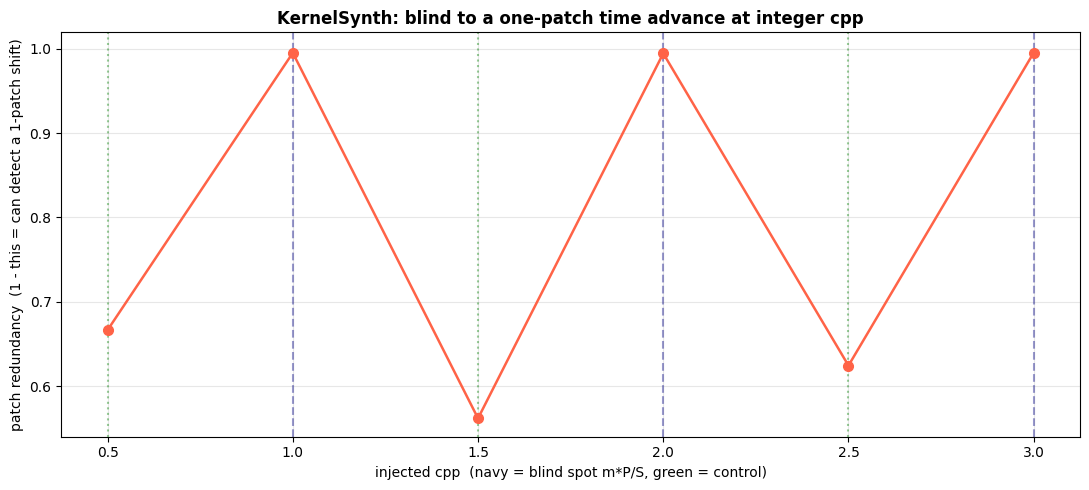

In [34]:
def sweep_plot(ax, data, metric, ylabel, title):
    sub = data[(data.generator==GENERATOR) & (data.phase==0.0) & (data.cpp.isin(SWEEP))]
    g = sub.groupby("cpp")[metric].agg(["mean","std"]).reset_index().sort_values("cpp")
    ax.errorbar(g["cpp"], g["mean"], yerr=g["std"].fillna(0), marker="o", ms=7, lw=1.8, capsize=3, color="tomato")
    for k in (1,2,3): ax.axvline(k, color="navy", ls="--", alpha=.4)
    for x in (0.5,1.5,2.5): ax.axvline(x, color="green", ls=":", alpha=.4)
    ax.set_xlabel("injected cpp  (navy = blind spot m*P/S, green = control)")
    ax.set_ylabel(ylabel); ax.set_title(title, fontweight="bold"); ax.grid(alpha=.3)

fig, ax = plt.subplots(figsize=(11, 5))
sweep_plot(ax, df, "redundancy", "patch redundancy  (1 - this = can detect a 1-patch shift)",
           f"{GENERATOR}: blind to a one-patch time advance at integer cpp")
plt.tight_layout(); plt.savefig(OUT/"S_redundancy.png", dpi=140, bbox_inches="tight"); plt.show()

*Peaks at integer cpp (redundancy -> 1) vs low at the green controls: on the blind spots the model cannot tell the signal advanced by one patch. That lost temporal observability is the structural-aliasing harm - distinct from forecast accuracy.*

## 2 - Detuning sharpness and phase-invariance

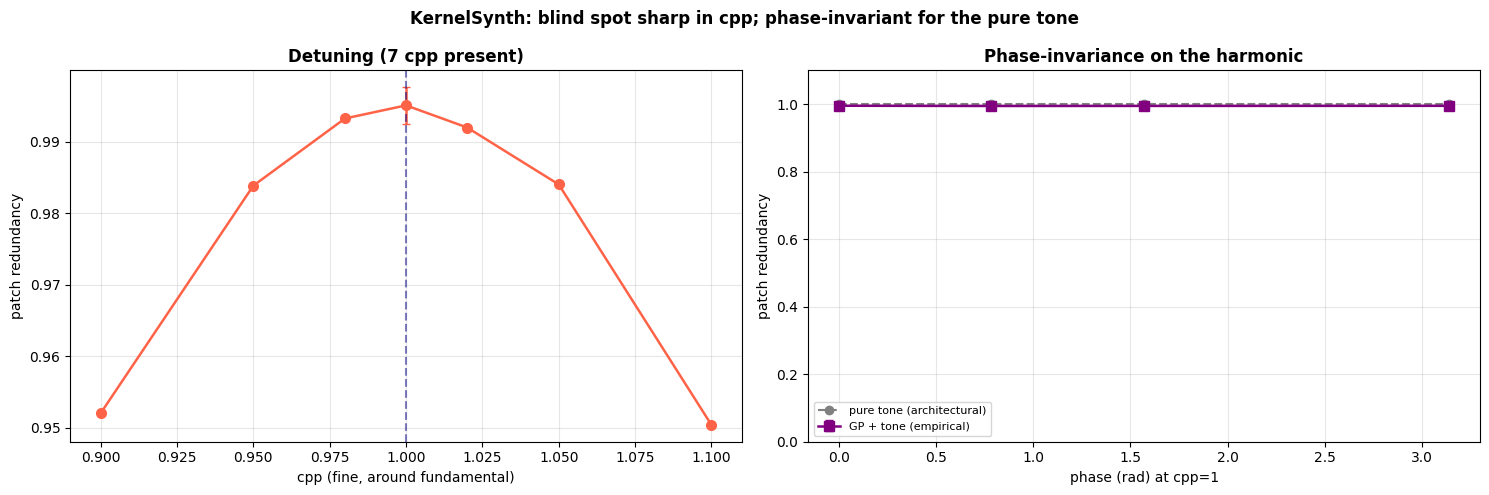

In [35]:
near = df[(df.generator==GENERATOR) & (df.phase==0.0) & (df.cpp.between(0.8, 1.2))]
gf = near.groupby("cpp")["redundancy"].agg(["mean","std"]).reset_index().sort_values("cpp")
ph = df[(df.generator==GENERATOR) & (df.cpp==1.0)]
gp = ph.groupby("phase")["redundancy"].agg(["mean","std"]).reset_index().sort_values("phase")
t = np.arange(512)
pure = [adjacent_cos(cut_into_patches(np.sin(2*np.pi*(1.0/P)*t + p), P, S_DEF)) for p in gp["phase"]]

fig, (a0, a1) = plt.subplots(1, 2, figsize=(15, 5))
a0.errorbar(gf["cpp"], gf["mean"], yerr=gf["std"].fillna(0), marker="o", ms=7, lw=1.8, capsize=3, color="tomato")
a0.axvline(1.0, color="navy", ls="--", alpha=.5)
a0.set_xlabel("cpp (fine, around fundamental)"); a0.set_ylabel("patch redundancy")
a0.set_title(f"Detuning ({len(gf)} cpp present)", fontweight="bold"); a0.grid(alpha=.3)
a1.errorbar(gp["phase"], gp["mean"], yerr=gp["std"].fillna(0), marker="s", ms=7, lw=1.8, capsize=3,
            color="purple", label="GP + tone (empirical)")
a1.plot(gp["phase"], pure, "o--", color="grey", label="pure tone (architectural)")
a1.set_ylim(0, 1.1); a1.set_xlabel("phase (rad) at cpp=1"); a1.set_ylabel("patch redundancy")
a1.set_title("Phase-invariance on the harmonic", fontweight="bold"); a1.legend(fontsize=8); a1.grid(alpha=.3)
plt.suptitle(f"{GENERATOR}: blind spot sharp in cpp; phase-invariant for the pure tone", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.savefig(OUT/"S_phase.png", dpi=140, bbox_inches="tight"); plt.show()

## 3 - Mitigation: overlap (S < P) restores rank

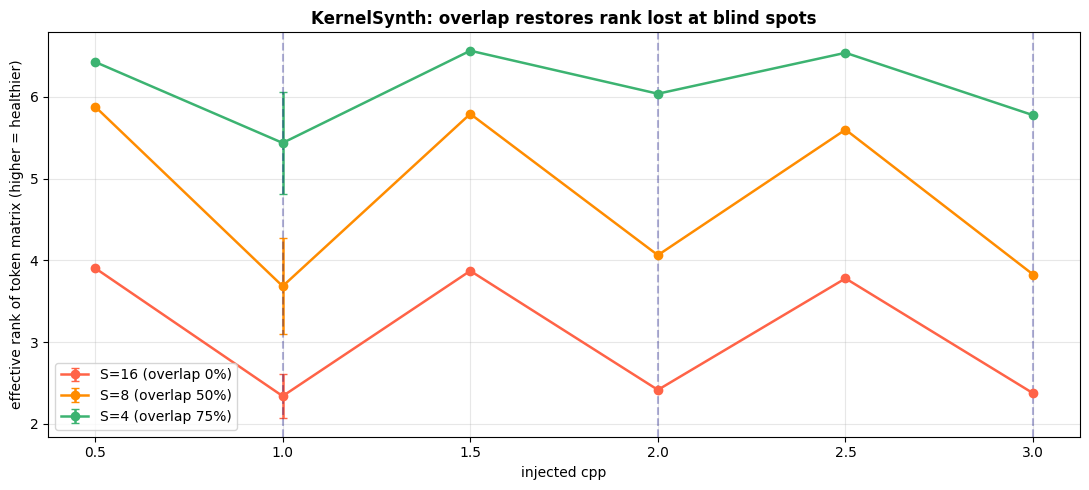

In [36]:
fig, ax = plt.subplots(figsize=(11, 5))
for stride, c in [(16, "tomato"), (8, "darkorange"), (4, "mediumseagreen")]:
    g = mit[mit.stride==stride].groupby("cpp")["eff_rank"].agg(["mean","std"]).reset_index().sort_values("cpp")
    ax.errorbar(g["cpp"], g["mean"], yerr=g["std"].fillna(0), marker="o", ms=6, lw=1.8, capsize=3,
                color=c, label=f"S={stride} (overlap {1-stride/P:.0%})")
for k in (1,2,3): ax.axvline(k, color="navy", ls="--", alpha=.3)
ax.set_xlabel("injected cpp"); ax.set_ylabel("effective rank of token matrix (higher = healthier)")
ax.set_title(f"{GENERATOR}: overlap restores rank lost at blind spots", fontweight="bold")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(OUT/"S_stride.png", dpi=140, bbox_inches="tight"); plt.show()

*Effective rank (not redundancy) is the right mitigation metric: redundancy is inflated by the samples that overlapping patches trivially share, whereas rank measures genuine token diversity. At integer cpp, S=16 collapses the rank; halving the stride restores it - overlap breaks the exact-repeat condition by moving blind spots to cpp = m*P/S.*

## Verdict
The critical generated-signal parameter is the **cycles-per-patch** of any periodic content. At integer
`cpp` (= `f*P/fs` hitting `m*P/S`) consecutive patches coincide, so the model is **blind to a one-patch
time advance** (redundancy -> 1); this is a representational loss, sharp in `cpp`, phase-invariant on the
harmonic, set by tokenisation not sampling, and mitigated by overlap (rank restored as `S` shrinks).